In [1]:
import tensorflow.keras
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Conv3D, Flatten, Dense, Reshape, BatchNormalization, Activation, MaxPooling3D, MaxPooling2D, Bidirectional
from tensorflow.keras.layers import InputLayer, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.utils import to_categorical

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, cohen_kappa_score 

from operator import truediv

from plotly.offline import init_notebook_mode
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.models import load_model

import numpy as np
import scipy.io as sio
from PIL import Image
import matplotlib.pyplot as plt
import geopandas as gdp
import pandas as pd
import sys
import os
import spectral
import argparse
import random
import time
from sklearn.metrics import f1_score
from scipy.ndimage import generic_filter
init_notebook_mode(connected=True)
%matplotlib inline

# %matplotlib notebook

# path='H:/3.6 all data/guangdong/LUtxt/'
# files_1 = os.listdir(path)
# print(files_1)
# print(files_1[0])

In [2]:
os.environ['CUDA_VISIBLE_DEVICES'] = '6'

In [3]:
import copy

In [4]:
import tensorflow as tf
print(tf.test.is_gpu_available())
# 检查是否使用GPU
if tf.test.gpu_device_name():
    print('GPU已安装')
else:
    print('GPU未安装')
    
import sys
print(sys.version)
import os
print(os.environ.get("CUDA_VISIBLE_DEVICES"))

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
True
GPU已安装
3.8.18 | packaged by conda-forge | (default, Dec 23 2023, 17:17:17) [MSC v.1929 64 bit (AMD64)]
6


In [5]:
#测试一下读取数据顺序
pa='D:/yangwei/zhangyu/A-N-CA/LU/'
fil=os.listdir(pa)
for i in range(5):
    print(fil[i])
print('lu....end...')
# pa='D:/yangwei/zhangyu/A-N-CA/driving/2010driving/'
# fil=os.listdir(pa)
# for i in range(8):
#     print(fil[i])
# print('10driving....end...')
# pa='D:/yangwei/zhangyu/A-N-CA/driving/2015driving/'
# fil=os.listdir(pa)
# for i in range(8):
#     print(fil[i])
# print('15driving....end...')

gd-lu-00-txt.txt
gd-lu-05-txt.txt
gd-lu-10-txt.txt
gd-lu-15-txt.txt
gd-lu-20-txt.txt
lu....end...


In [6]:
#定义基本参数
paths=['2000driving-2/','2005driving-2/','2010driving-2/','2015driving-2/']
year = 3
channel=13
windowSize=11
test_ratio = 0.7

In [7]:
def loadData(tel = 0): #例：驱动：00，05 LU：05，10
    pathLU='D:/yangwei/zhangyu/A-N-CA/LU/'
    pathDV='D:/yangwei/zhangyu/A-N-CA/driving/'
    A = np.zeros((605,755))
    B = np.zeros((605,755))
    C = np.zeros((605,755,3,9))
    
    driv1=pathDV+paths[tel]
    filesdriv1=os.listdir(driv1)
    driv2=pathDV+paths[1+tel]
    filesdriv2=os.listdir(driv2)
    driv3=pathDV+paths[2+tel]
    filesdriv3=os.listdir(driv3)
    for i in range(9):
        C[:,:,0,i] = np.loadtxt(driv1+filesdriv1[i])
        C[:,:,1,i] = np.loadtxt(driv2+filesdriv2[i])
        C[:,:,2,i] = np.loadtxt(driv2+filesdriv2[i])
        print('load...wait...'+str(i))
    files=os.listdir(pathLU)
    A = np.loadtxt(pathLU+files[2+tel])
    B = np.loadtxt(pathLU+files[3+tel])
    return A, B, C

In [8]:
#1.读取数据
A, B, C = loadData(tel=0)   #A:2005LU  B：2010LU  C：2000-2005 driving
A = A-1
B = B-1
A2010 = copy.deepcopy(A) #每轮CA模拟LU过程的初始状态
true_2015 = copy.deepcopy(B) 

load...wait...0
load...wait...1
load...wait...2
load...wait...3
load...wait...4
load...wait...5
load...wait...6
load...wait...7
load...wait...8


In [9]:
A2, B2, C2 = loadData(tel=1)#A2:2010LU  B2：2015LU  C2：2005-2010 driving
A2 = A2-1
B2 = B2-1
true_2020 = copy.deepcopy(B2) 

load...wait...0
load...wait...1
load...wait...2
load...wait...3
load...wait...4
load...wait...5
load...wait...6
load...wait...7
load...wait...8


In [10]:
def padWithZeros(X, margin=5):#605,755,8   5 
    newX = np.zeros((X.shape[0] + 2 * margin, X.shape[1] + 2* margin, 3, 9))#605,755,8    
    x_offset = margin
    y_offset = margin
    newX[x_offset:X.shape[0] + x_offset, y_offset:X.shape[1] + y_offset, :, : ] = X
    return newX # 615,765 ,3,8

In [11]:
def createImageCubes1(A, B, C): #output： A1, B1, C1, T
    margin = int((windowSize - 1) / 2) # 5
    zeroPaddedX = padWithZeros(C, margin=margin)#615,765,8 LU图扩大5像素
    patchesData = np.zeros((A.shape[0] * A.shape[1], windowSize, windowSize, C.shape[2],C.shape[3]))#456775,11,11,8
    patchesLabelsi = np.zeros((A.shape[0] * A.shape[1]))#456775
    patchesLabelsf = np.zeros((A.shape[0] * A.shape[1]))#456775 
    T = np.zeros((A.shape[0] * A.shape[1],2)) #定标
    patchIndex = 0
    for r in range(margin, zeroPaddedX.shape[0] - margin):#5,610
        for c in range(margin, zeroPaddedX.shape[1] - margin):#5,760
            patch = zeroPaddedX[r - margin:r + margin + 1, c - margin:c + margin + 1,:,:]
            patchesData[patchIndex, :, :, :, :] = patch      
            patchesLabelsi[patchIndex] = A[r-margin, c-margin]
            patchesLabelsf[patchIndex] = B[r-margin, c-margin]
            T[patchIndex, :] = [r - margin, c - margin]
            patchIndex = patchIndex + 1
    print('wait...patchindex＝:'+str(patchIndex))
    patchesData = patchesData[patchesLabelsi>-1,:,:,:,:] #样本有用
    T = T[patchesLabelsi>-1,:]
    patchesLabelsf = patchesLabelsf[patchesLabelsi>-1]
    patchesLabelsi = patchesLabelsi[patchesLabelsi>-1]
    t = 0
    for i in range (patchesLabelsi.shape[0]):
        if int(patchesLabelsf[i])>-1 and int(patchesLabelsi[i])>-1 :
            patchesData[t, :, :, :, :] = patchesData[i, :, :, :, :]
            patchesLabelsi[t] = patchesLabelsi[i]
            patchesLabelsf[t] = patchesLabelsf[i]
            T[t,:] = T[i,:]  
            t = t+1
    patchesDataC = patchesData[0:t, :, :, :, :]
    patchesLabelsA = patchesLabelsi[0:t] #f 或者i，标签 10年
    patchesLabelsB = patchesLabelsf[0:t] #f 或者i，标签 15年
    T_T = T[0:t,:]
    # 遍历数组中的每个元素
    for i in range(patchesDataC.shape[0]):  # 遍历样本 (t)
        for k in range(patchesDataC.shape[3]):  # 遍历新增维度 (2)
            for j in range(patchesDataC.shape[4]):  # 遍历通道 (9)
                window = patchesDataC[i, :, :, k, j]  # 取出窗口
                if -9999 in window:
                    # 计算窗口中非-9999的平均值
                    valid_values = window[window != -9999]
    
                    if valid_values.size > 0:  # 检查是否存在正常值
                        mean_val = np.mean(valid_values)  # 存在正常值，计算平均值
                    else:
                        mean_val = 0  # 不存在正常值，设置为 0
    
                    # 替换-9999值
                    window[window == -9999] = mean_val
                    patchesDataC[i, :, :, k, j] = window  # 替换回原数据

    return patchesLabelsA, patchesLabelsB, patchesDataC, T_T

In [12]:
#2.windows裁剪大小，实际 存在的样本和标签
A1, B1, C1, T = createImageCubes1(A, B, C)  #A1:2010LU实际数据样本集  B1：2015LU实际数据样本集 C1：对应2000-2005-2010 Driving T:真实数据在LU中的位置
print(A1.shape, B1.shape, C1.shape, T.shape)

wait...patchindex＝:456775
(176011,) (176011,) (176011, 11, 11, 3, 9) (176011, 2)


In [13]:
#2.windows裁剪大小，实际 存在的样本和标签
A12, B12, C12, T2 = createImageCubes1(A2, B2, C2)  #A12:2015LU实际数据样本集  B12：2020LU实际数据样本集 C12：对应2005-2010-2015 Driving T2:真实数据在LU中的位置
print(A12.shape, B12.shape, C12.shape, T2.shape)

wait...patchindex＝:456775
(176011,) (176011,) (176011, 11, 11, 3, 9) (176011, 2)


In [14]:
T = T.astype(int)
T2 = T2.astype(int)

In [15]:
# 找到 C1 中的 NaN 值位置
nan_indices = np.isnan(C1)
# 将 NaN 值位置的值填充为 0
C1[nan_indices] = 0

# 找到 C1 中的 NaN 值位置
nan_indices = np.isnan(C12)
# 将 NaN 值位置的值填充为 0
C12[nan_indices] = 0

In [16]:
def change(A1, B1):  #二元回归的话使用，目前使用多元回归，所以不使用
    D = B1 - A1
    D = np.where(D == 0, 0, 1)
    return D

In [17]:
# 3.LR处理对应的标签，2015-2010 ; 0则没有变化，其他为变化   目前不使用
D = change(A1, B1)
D2 = change(A12, B12)

In [17]:
#4.LR训练，选取样本集

In [18]:
# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(C1, B1, test_size=0.3, random_state=345)

In [19]:
# 标签
y_train = to_categorical(y_train) #训练标签
y_test = to_categorical(y_test) #验证标签

In [20]:
## input layer
input_layer = Input((windowSize, windowSize, year, 9))
conv_layer1 = Conv3D(filters=20, kernel_size=(7, 7, 3), activation='relu', padding='SAME')(input_layer) ##conv3d
maxpool1=MaxPooling3D(pool_size=(2, 2, 1), padding='VALID')(conv_layer1)##maxpoll
# conv_layer3 = Conv3D(filters=20, kernel_size=(5, 5, 2), activation='relu', padding='SAME')(maxpool1)##conv2d
# maxpool2=MaxPooling3D(pool_size=(2, 2, 1), padding='VALID')(conv_layer3)##maxpoll
conv_layer4 = Conv3D(filters=40, kernel_size=(3, 3, 2), activation='relu', padding='SAME')(maxpool1)##conv2d
maxpool3=MaxPooling3D(pool_size=(2, 2, 2), padding='VALID')(conv_layer4)##maxpoll
flatten_layer = Flatten()(maxpool3)##展开
## fully connected layers
dense_layer1 = Dense(units=200, activation='relu')(flatten_layer)
dense_layer1 = Dropout(0.2)(dense_layer1)
# dense_layer2 = Dense(units=128, activation='relu')(dense_layer1)
# dense_layer2 = Dropout(0.6)(dense_layer2)
output_layer = Dense(units=6, activation='softmax')(dense_layer1)
model_3DCNN = Model(inputs=input_layer, outputs=output_layer)
model_3DCNN.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 11, 11, 3, 9)]    0         
_________________________________________________________________
conv3d (Conv3D)              (None, 11, 11, 3, 20)     26480     
_________________________________________________________________
max_pooling3d (MaxPooling3D) (None, 5, 5, 3, 20)       0         
_________________________________________________________________
conv3d_1 (Conv3D)            (None, 5, 5, 3, 40)       14440     
_________________________________________________________________
max_pooling3d_1 (MaxPooling3 (None, 2, 2, 1, 40)       0         
_________________________________________________________________
flatten (Flatten)            (None, 160)               0         
_________________________________________________________________
dense (Dense)                (None, 200)               32200 

In [21]:
adam = Adam(learning_rate=0.001, decay=1e-06)
model_3DCNN.compile(optimizer=adam,loss='categorical_crossentropy',  metrics=['accuracy'])

In [22]:
# checkpoint
filepath_3DCNN = "C:\\Users\\yangwei\\Desktop\\A-N-CA-model-3\\11-26\\3DCNN-1.hdf5"
checkpoint = ModelCheckpoint(filepath_3DCNN, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')
callbacks_list_3DCNN = [checkpoint]

In [19]:
# 训练模型
# model_3DCNN.fit(x=X_train, y=y_train, batch_size=64, epochs=20, callbacks=callbacks_list_3DCNN, validation_data=(X_test, y_test))

In [727]:
#jieshu

In [18]:
model_test_3DCNN_1 = load_model('C:\\Users\\yangwei\\Desktop\\other-model\\3DCNN-CA\\3DCNN-2.hdf5')
Y_pred_test_3DCNN_1 = model_test_3DCNN_1.predict(C1) #预测预测集

y_pred_test_3DCNN_1 = np.argmax(Y_pred_test_3DCNN_1, axis=1)#预测结果最大的

classification_3DCNN_1 = classification_report(B1, y_pred_test_3DCNN_1)
print(classification_3DCNN_1)

              precision    recall  f1-score   support

         0.0       0.83      0.86      0.84     42413
         1.0       0.94      0.95      0.94    106221
         2.0       0.80      0.77      0.78      7778
         3.0       0.76      0.80      0.78      7029
         4.0       0.81      0.70      0.75     12445
         5.0       0.85      0.28      0.42       125

    accuracy                           0.89    176011
   macro avg       0.83      0.72      0.75    176011
weighted avg       0.89      0.89      0.89    176011



In [19]:
Y_pred_test_3DCNN_2 = model_test_3DCNN_1.predict(C12) #预测预测集

y_pred_test_3DCNN_2 = np.argmax(Y_pred_test_3DCNN_2, axis=1)#预测结果最大的

classification_3DCNN_2 = classification_report(B12, y_pred_test_3DCNN_2)
print(classification_3DCNN_2)

              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98     40782
         1.0       0.99      1.00      1.00    106918
         2.0       0.99      0.94      0.96      7707
         3.0       0.93      0.91      0.92      7298
         4.0       0.89      0.89      0.89     13199
         5.0       1.00      0.05      0.09       107

    accuracy                           0.98    176011
   macro avg       0.96      0.79      0.81    176011
weighted avg       0.98      0.98      0.98    176011



In [20]:
# print(Y_pred_test_LR.shape)
# print(E1.shape)
# print(A1.shape)

In [21]:
# 生成 E1，计算差值
E1 = y_pred_test_3DCNN_1 - A1  # 计算差值
# 创建最终的 E1 数组
E1 = np.where(E1 == 0, 0, 1)  # 如果差值为 0，则 E1 对应位置为 0；否则为 1

# 生成 E1，计算差值
E2 = y_pred_test_3DCNN_2 - A12  # 计算差值
# 创建最终的 E1 数组
E2 = np.where(E2 == 0, 0, 1)  # 如果差值为 0，则 E1 对应位置为 0；否则为 1

In [22]:
# 统计同位置为 1 的数量
count = np.sum((D == 1) & (E1 == 1))

# 输出结果
print(f"Number of positions where both D and E1 are 1: {count}")

Number of positions where both D and E1 are 1: 1761


In [23]:
count2 = np.sum(D == 1)
print(f"Number of positions where both D are 1: {count2}")

Number of positions where both D are 1: 18899


In [24]:
# 统计同位置为 1 的数量
count3 = np.sum((D2 == 1) & (E2 == 1))

# 输出结果
print(f"Number of positions where both D2 and E2 are 1: {count3}")

Number of positions where both D2 and E2 are 1: 17904


In [25]:
count4 = np.sum(D2 == 1)
print(f"Number of positions where both D2 are 1: {count4}")

Number of positions where both D2 are 1: 19195


In [26]:
# 初始化 P0 为 -10000，形状为 (605, 755, 6)
P0 = np.full((605, 755, 6), -10000, dtype=np.float32)
# 使用 T 中的索引，将 Y_pred_test_3DCNN_1[:, :6] 的值赋给 P0 对应位置
P0[T[:, 0], T[:, 1], :] = Y_pred_test_3DCNN_1[:, :6]
print(P0.shape)

(605, 755, 6)


In [27]:
# print(P0[300,390,:])
# print(Y_pred_test_3DCNN_1[100,:])

In [28]:
# 初始化 P0 为 -10000，形状为 (605, 755, 6)
P4 = np.full((605, 755, 6), -10000, dtype=np.float32)
# 使用 T 中的索引，将 Y_pred_test_3DCNN_1[:, :6] 的值赋给 P0 对应位置
P4[T2[:, 0], T2[:, 1], :] = Y_pred_test_3DCNN_2[:, :6]
print(P4.shape)

(605, 755, 6)


In [29]:
#开始NCA预先训练！！！

In [30]:
# 定义 CNN 模型
def build_land_use_cnn():
    input_layer = Input(shape=(windowSize, windowSize, 13))
    x = Conv2D(filters=15, kernel_size=(7, 7), activation='relu', padding='SAME')(input_layer)
    x = MaxPooling2D(pool_size=(2, 2), padding='VALID')(x)
    x = Conv2D(filters=30, kernel_size=(3, 3), activation='relu', padding='SAME')(x)
    x = MaxPooling2D(pool_size=(2, 2), padding='VALID')(x)
    x = Flatten()(x)
    x = Dense(50, activation='relu')(x)
    x = Dropout(0.2)(x)
    output_layer = Dense(6, activation='softmax')(x)  # 六类土地类型的输出
    model = Model(inputs=input_layer, outputs=output_layer)
    return model

In [31]:
model_CNN = build_land_use_cnn()

In [32]:

optimizer = Adam(learning_rate=0.001)
model_CNN.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [33]:
# checkpoint
filepath_CNN = "C:\\Users\\yangwei\\Desktop\\other-model\\Conv-7\\CNN-conv-7.h5"
checkpoint_CNN = ModelCheckpoint(filepath_CNN, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')
callbacks_list_CNN = [checkpoint_CNN]

In [34]:
# 邻域统计函数
def compute_neighborhood_stats2(A):
    stats = np.zeros((A.shape[0], A.shape[1], 6))-10000  # 每个栅格点的邻域统计信息
    for land_type in range(6):
        mask = (A == land_type).astype(np.float32)
        stats[:, :, land_type] = tf.nn.conv2d(
            mask[np.newaxis, :, :, np.newaxis],
            filters=np.ones((3, 3, 1, 1)), 
            strides=1, padding="SAME").numpy().squeeze() / 9
    return stats

In [35]:
# 创建每个选取点及其邻域的输入数据 A0
def create_A0(A, P, T):
    A0 = []
    neighborhood_stats = compute_neighborhood_stats2(A)
    
    for i, (x, y) in enumerate(T):
        # 初始化 11x11 的邻域区域，并处理边界超出区域
        neighborhood_A = np.full((11, 11), -10000, dtype=A.dtype)
        neighborhood_P = np.full((11, 11, 6), -10000, dtype=P.dtype)
        neighborhood_stats_patch = np.full((11, 11, 6), -10000, dtype=neighborhood_stats.dtype)
        
        # 确定邻域的有效范围，避免超出边界
        x_min = max(0, x - 5)
        x_max = min(A.shape[0], x + 6)
        y_min = max(0, y - 5)
        y_max = min(A.shape[1], y + 6)
        
        # 计算在 11x11 网格中的相对位置
        neighborhood_A[(x_min - x + 5):(x_max - x + 5), (y_min - y + 5):(y_max - y + 5)] = A[x_min:x_max, y_min:y_max]
        neighborhood_P[(x_min - x + 5):(x_max - x + 5), (y_min - y + 5):(y_max - y + 5), :] = P[x_min:x_max, y_min:y_max, :]
        neighborhood_stats_patch[(x_min - x + 5):(x_max - x + 5), (y_min - y + 5):(y_max - y + 5), :] = neighborhood_stats[x_min:x_max, y_min:y_max, :]
        
        # 初始化 11x11x8 特征矩阵，并填充对应通道
        neighborhood_features = np.zeros((11, 11, 13))
        neighborhood_features[:, :, 0] = neighborhood_A
        neighborhood_features[:, :, 1:7] = neighborhood_P
        neighborhood_features[:, :, 7:13] = neighborhood_stats_patch

        # 检查是否存在 -10000，如果存在，则用非 -10000 的均值替换
        mask = (neighborhood_features != -10000)
        for channe in range(13):
            valid_values = neighborhood_features[:, :, channe][mask[:, :, channe]]
            if valid_values.size > 0:
                mean_value = valid_values.mean()
                neighborhood_features[:, :, channe][~mask[:, :, channe]] = mean_value
            else:
                # 如果整个区域为 -10000，则替换为 0
                neighborhood_features[:, :, channe].fill(0)
        
        A0.append(neighborhood_features)
    
    return np.array(A0)

In [36]:
def calculate_fom(A, B, C):
    # 计算变化的情况，不包括真实和预测都不变的情况
    actual_change = tf.not_equal(A, B)
    predicted_change = tf.not_equal(A, C)

    # 真实变化与预测变化都发生的区域
    correct_prediction = tf.logical_and(actual_change, tf.equal(B, C))

    # 计算分子：正确预测的变化样本数
    numerator = tf.reduce_sum(tf.cast(correct_prediction, tf.float32))

    # 计算分母：所有实际变化的样本数加上所有错误预测的变化样本数
    denominator = tf.reduce_sum(tf.cast(actual_change, tf.float32)) + tf.reduce_sum(tf.cast(tf.logical_and(tf.logical_not(actual_change), predicted_change), tf.float32))

    # 计算FOM
    fom = numerator / denominator
    return fom.numpy()

In [37]:
A_state = copy.deepcopy(A2010)
A0 = create_A0(A_state, P0, T)

In [38]:
# # 划分训练集和测试集
# X_train_CNN, X_test_CNN, y_train_CNN, y_test_CNN = train_test_split(A0, B1, test_size=0.3, random_state=345)

In [39]:
A_state2 = copy.deepcopy(true_2015)
A0_test = create_A0(A_state2, P4, T2)

In [40]:
# # 标签
# y_train_CNN = to_categorical(y_train_CNN) #训练标签
# y_test_CNN = to_categorical(y_test_CNN) #验证标签

In [41]:
y_train_CNN = to_categorical(B1) #训练标签
y_test_CNN = to_categorical(B12) #验证标签

In [42]:

print(y_train_CNN.shape,y_test_CNN.shape)

(176011, 6) (176011, 6)


In [43]:
model_CNN.fit(x=A0, y=y_train_CNN, batch_size=64, epochs=20, callbacks=callbacks_list_CNN, validation_data=(A0_test, y_test_CNN))

Epoch 1/20
2751/2751 [==============================] - 13s 4ms/step - loss: 0.5306 - accuracy: 0.8405 - val_loss: 0.2489 - val_accuracy: 0.9462

Epoch 00001: val_accuracy improved from -inf to 0.94615, saving model to C:\Users\yangwei\Desktop\other-model\Conv-7\CNN-conv-7.h5
Epoch 2/20
2751/2751 [==============================] - 11s 4ms/step - loss: 0.4238 - accuracy: 0.8893 - val_loss: 0.2183 - val_accuracy: 0.9574

Epoch 00002: val_accuracy improved from 0.94615 to 0.95739, saving model to C:\Users\yangwei\Desktop\other-model\Conv-7\CNN-conv-7.h5
Epoch 3/20
2751/2751 [==============================] - 9s 3ms/step - loss: 0.4122 - accuracy: 0.8925 - val_loss: 0.2152 - val_accuracy: 0.9571

Epoch 00003: val_accuracy did not improve from 0.95739
Epoch 4/20
2751/2751 [==============================] - 13s 5ms/step - loss: 0.4049 - accuracy: 0.8934 - val_loss: 0.2167 - val_accuracy: 0.9513

Epoch 00004: val_accuracy did not improve from 0.95739
Epoch 5/20
2751/2751 [====================

In [45]:
# model_CNN.fit(x=X_train_CNN, y=y_train_CNN, batch_size=64, epochs=20, callbacks=callbacks_list_CNN, validation_data=(X_test_CNN, y_test_CNN))

In [44]:
#预训练但不5次迭代的结果，2015
model_test_CNN_1 = load_model('C:\\Users\\yangwei\\Desktop\\other-model\\Conv-7\\CNN-conv-7.h5')
Y_pred_test_CNN_1 = model_test_CNN_1.predict(A0) #预测预测集

y_pred_test_CNN_1 = np.argmax(Y_pred_test_CNN_1, axis=1)#预测结果最大的

classification_CNN_1 = classification_report(B1, y_pred_test_CNN_1)
print(classification_CNN_1)

              precision    recall  f1-score   support

         0.0       0.85      0.85      0.85     42413
         1.0       0.94      0.95      0.94    106221
         2.0       0.80      0.77      0.79      7778
         3.0       0.76      0.81      0.78      7029
         4.0       0.80      0.75      0.78     12445
         5.0       0.67      0.62      0.65       125

    accuracy                           0.90    176011
   macro avg       0.80      0.79      0.80    176011
weighted avg       0.90      0.90      0.90    176011



In [45]:
#预训练但不5次迭代的结果，2015
model_test_CNN_1 = load_model('C:\\Users\\yangwei\\Desktop\\other-model\\Conv-7\\CNN-conv-7.h5')
Y_pred_test_CNN_1 = model_test_CNN_1.predict(A0_test) #预测预测集

y_pred_test_CNN_1 = np.argmax(Y_pred_test_CNN_1, axis=1)#预测结果最大的

classification_CNN_1 = classification_report(B12, y_pred_test_CNN_1)
print(classification_CNN_1)

              precision    recall  f1-score   support

         0.0       0.94      0.95      0.94     40782
         1.0       0.99      0.99      0.99    106918
         2.0       0.97      0.92      0.95      7707
         3.0       0.88      0.85      0.87      7298
         4.0       0.79      0.81      0.80     13199
         5.0       0.49      0.54      0.52       107

    accuracy                           0.96    176011
   macro avg       0.85      0.84      0.84    176011
weighted avg       0.96      0.96      0.96    176011



In [46]:
fom = calculate_fom(A12, B12, y_pred_test_CNN_1)
print("FOM值:", fom)
# 计算总体精度
accuracy = tf.reduce_mean(tf.cast(tf.equal(B12, y_pred_test_CNN_1), tf.float32))
# 打印结果
print("总体精度:", accuracy.numpy())

FOM值: 0.63944584
总体精度: 0.9580083


In [47]:
model_CNN.load_weights('C:\\Users\\yangwei\\Desktop\\other-model\\Conv-7\\CNN-conv-7.h5')

In [48]:
#使用预训练的cnn迭代5次，模拟2015
A_state2 = copy.deepcopy(true_2015)
for year in range(5):
    print(f"yxz...simulate_land_use...: {year}")
    # 获取当前状态输入，A0 形状为 (160000, 11, 11, 8)
    A0 = create_A0(A_state2, P4, T2)
    print(f"yxz...A0...: {year}")
    # 前向传播，land_type_logits 形状为 (160000, 6)
    land_type_logits = model_CNN(A0, training=False)
    print(f"yxz...model...: {year}")
    # 获取预测类别，形状为 (160000,)
    predicted_land_types = tf.argmax(land_type_logits, axis=-1)

    # 生成随机数数组 Asy
    Asy = tf.random.uniform(shape=(len(T2),), minval=0.0, maxval=1.0)  # 随机生成范围 [0, 1)
    # 更新土地利用图状态，将预测的类别应用到 A_state 中
    for i, (x, y) in enumerate(T2):
        if Asy[i] > 0.5:  # 判断随机数是否大于 0.5
            A_state2[x, y] = predicted_land_types[i]
        
print(f"yxz...2015-2020...end...")


yxz...simulate_land_use...: 0
yxz...A0...: 0
yxz...model...: 0
yxz...simulate_land_use...: 1
yxz...A0...: 1
yxz...model...: 1
yxz...simulate_land_use...: 2
yxz...A0...: 2
yxz...model...: 2
yxz...simulate_land_use...: 3
yxz...A0...: 3
yxz...model...: 3
yxz...simulate_land_use...: 4
yxz...A0...: 4
yxz...model...: 4
yxz...2015-2020...end...


In [49]:
#在预训练后的cnn效果，模拟2020结果
predicted_2020_flat = tf.gather_nd(A_state2, T2)

fom = calculate_fom(A12, B12, predicted_2020_flat)
print("FOM值:", fom)
# 计算总体精度
best_accuracy = tf.reduce_mean(tf.cast(tf.equal(B12, predicted_2020_flat), tf.float32))
# 打印结果
print("总体精度:", best_accuracy.numpy())

FOM值: 0.62355214
总体精度: 0.9556846


In [50]:
# 自定义训练循环
epochs = 10

In [51]:
 # 加载预训练模型
# model_CNN.load_weights(filepath_CNN)

# 定义损失函数和优化器（可与预训练相同或新的设置）
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()
optimizer = Adam(learning_rate=0.0001)

In [52]:
print("yxz...GradientTape...loading...")

for epoch in range(epochs):
    print(f"epoch...loading...: {epoch}")
    with tf.GradientTape() as tape:
        total_loss = 0  # 累积每步的损失
        A_state = copy.deepcopy(A2010)  # 初始土地利用状态

        # 模拟逐年土地利用变化
        for year in range(5):
            print(f"yxz...simulate_land_use...: {year}")
            # 获取当前状态输入，A0 形状为 (160000, 11, 11, 8)
            A0 = create_A0(A_state, P0, T)
            print(f"yxz...A0...: {year}")
            # 前向传播，land_type_logits 形状为 (160000, 6)
            land_type_logits = model_CNN(A0, training=True)
            print(f"yxz...model...: {year}")
            # 计算交叉熵损失
            true_labels = tf.gather_nd(true_2015, T)  # 提取 T 点对应的真实类别标签，形状为 (160000,)
            loss_step = tf.reduce_mean(tf.keras.losses.sparse_categorical_crossentropy(true_labels, land_type_logits))
            total_loss += loss_step  # 累加每年的损失

            # 获取预测类别，形状为 (160000,)
            predicted_land_types = tf.argmax(land_type_logits, axis=-1)

            # 生成随机数数组 Asy
            Asy = tf.random.uniform(shape=(len(T),), minval=0.0, maxval=1.0)  # 随机生成范围 [0, 1)
            # 更新土地利用图状态，将预测的类别应用到 A_state 中
            for i, (x, y) in enumerate(T):
                if Asy[i] > 0.5:  # 判断随机数是否大于 0.5
                    A_state[x, y] = predicted_land_types[i]
                
        # 平均损失并应用反向传播
        total_loss /= 5
        gradients = tape.gradient(total_loss, model_CNN.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model_CNN.trainable_variables))

    # 使用生成的 2010 年数据预测 2015 年土地利用并计算验证精度
    print(f"yxz...2015-2020...loading...")
    A_state2 = copy.deepcopy(true_2015)
    for year in range(5):
        print(f"yxz...simulate_land_use...: {year}")
        # 获取当前状态输入，A0 形状为 (160000, 11, 11, 8)
        A0 = create_A0(A_state2, P4, T2)
        print(f"yxz...A0...: {year}")
        # 前向传播，land_type_logits 形状为 (160000, 6)
        land_type_logits = model_CNN(A0, training=False)
        print(f"yxz...model...: {year}")
        # 获取预测类别，形状为 (160000,)
        predicted_land_types = tf.argmax(land_type_logits, axis=-1)

        # 生成随机数数组 Asy
        Asy = tf.random.uniform(shape=(len(T2),), minval=0.0, maxval=1.0)  # 随机生成范围 [0, 1)
        # 更新土地利用图状态，将预测的类别应用到 A_state 中
        for i, (x, y) in enumerate(T2):
            if Asy[i] > 0.5:  # 判断随机数是否大于 0.5
                A_state2[x, y] = predicted_land_types[i]
            
    print(f"yxz...2015-2020...end...")
    # 根据T提取对应位置的预测结果和真实值
    predicted_2020_flat = tf.gather_nd(A_state2, T2)
    true_2020_flat = tf.gather_nd(true_2020, T2)
    
    accuracy = np.mean(predicted_2020_flat == true_2020_flat)
    print(f'Validation Accuracy for 2020 Prediction: {accuracy * 100:.4f}%')

    # 保存最佳模型
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        model_CNN.save('C:\\Users\\yangwei\\Desktop\\other-model\\Conv-7\\Best-CNN-conv-7.h5')
        print(f"New best model saved with accuracy: {best_accuracy * 100:.4f}%")

    print(f"Epoch {epoch + 1}/{epochs}, Loss: {total_loss.numpy()}")
    print("yxz...GradientTape...end...")


yxz...GradientTape...loading...
epoch...loading...: 0
yxz...simulate_land_use...: 0
yxz...A0...: 0
yxz...model...: 0
yxz...simulate_land_use...: 1
yxz...A0...: 1
yxz...model...: 1
yxz...simulate_land_use...: 2
yxz...A0...: 2
yxz...model...: 2
yxz...simulate_land_use...: 3
yxz...A0...: 3
yxz...model...: 3
yxz...simulate_land_use...: 4
yxz...A0...: 4
yxz...model...: 4
yxz...2015-2020...loading...
yxz...simulate_land_use...: 0
yxz...A0...: 0
yxz...model...: 0
yxz...simulate_land_use...: 1
yxz...A0...: 1
yxz...model...: 1
yxz...simulate_land_use...: 2
yxz...A0...: 2
yxz...model...: 2
yxz...simulate_land_use...: 3
yxz...A0...: 3
yxz...model...: 3
yxz...simulate_land_use...: 4
yxz...A0...: 4
yxz...model...: 4
yxz...2015-2020...end...
Validation Accuracy for 2020 Prediction: 95.5724%
New best model saved with accuracy: 95.5724%
Epoch 1/10, Loss: 0.38855209946632385
yxz...GradientTape...end...
epoch...loading...: 1
yxz...simulate_land_use...: 0
yxz...A0...: 0
yxz...model...: 0
yxz...simulate_l

In [53]:
model_CNN.load_weights('C:\\Users\\yangwei\\Desktop\\other-model\\Conv-7\\Best-CNN-conv-7.h5')

In [54]:
#使用预训练的cnn迭代5次，模拟2020
A_state2 = copy.deepcopy(true_2015)
for year in range(5):
    print(f"yxz...simulate_land_use...: {year}")
    # 获取当前状态输入，A0 形状为 (160000, 11, 11, 8)
    A0 = create_A0(A_state2, P4, T2)
    print(f"yxz...A0...: {year}")
    # 前向传播，land_type_logits 形状为 (160000, 6)
    land_type_logits = model_CNN(A0, training=False)
    print(f"yxz...model...: {year}")
    # 获取预测类别，形状为 (160000,)
    predicted_land_types = tf.argmax(land_type_logits, axis=-1)

    # 生成随机数数组 Asy
    Asy = tf.random.uniform(shape=(len(T2),), minval=0.0, maxval=1.0)  # 随机生成范围 [0, 1)
    # 更新土地利用图状态，将预测的类别应用到 A_state 中
    for i, (x, y) in enumerate(T2):
        if Asy[i] > 0.5:  # 判断随机数是否大于 0.5
            A_state2[x, y] = predicted_land_types[i]
        
print(f"yxz...2015-2020...end...")

yxz...simulate_land_use...: 0
yxz...A0...: 0
yxz...model...: 0
yxz...simulate_land_use...: 1
yxz...A0...: 1
yxz...model...: 1
yxz...simulate_land_use...: 2
yxz...A0...: 2
yxz...model...: 2
yxz...simulate_land_use...: 3
yxz...A0...: 3
yxz...model...: 3
yxz...simulate_land_use...: 4
yxz...A0...: 4
yxz...model...: 4
yxz...2015-2020...end...


In [55]:
print(A_state2.shape)
predicted_2020_flat = tf.gather_nd(A_state2, T2)
fom = calculate_fom(A12, B12, predicted_2020_flat)
print("FOM值:", fom)
# 计算总体精度
accuracy = tf.reduce_mean(tf.cast(tf.equal(B12, predicted_2020_flat), tf.float32))
# 打印结果
print("总体精度:", accuracy.numpy())

(605, 755)
FOM值: 0.62540007
总体精度: 0.9561107


In [56]:
# 使用scikit-learn计算每个类别的F1-score
f1_scores_per_class = f1_score(B12, predicted_2020_flat, average=None)
# 计算平均F1-score
average_f1_score = f1_score(B12, predicted_2020_flat, average='weighted')
print("F1-scores for each class:", f1_scores_per_class)
print("Average F1-score:", average_f1_score)

F1-scores for each class: [0.94167679 0.98917552 0.93788194 0.86102225 0.79943026 0.52293578]
Average F1-score: 0.9560979791578318


In [57]:
# 计算Kappa系数
kappa = cohen_kappa_score(B12, predicted_2020_flat)
print('Kappa系数:', kappa)

Kappa系数: 0.9226097839183598


In [58]:
# 循环结束后计算并打印混淆矩阵
conf_matrix = confusion_matrix(B12, predicted_2020_flat)
print("最终的混淆矩阵:\n", conf_matrix)

最终的混淆矩阵:
 [[ 38750    295     47    205   1477      8]
 [   355 105776     56     85    636     10]
 [   234    144   6983    208    126     12]
 [   449    213     28   6056    546      6]
 [  1722    514     69    212  10664     18]
 [     8      7      1      3     31     57]]


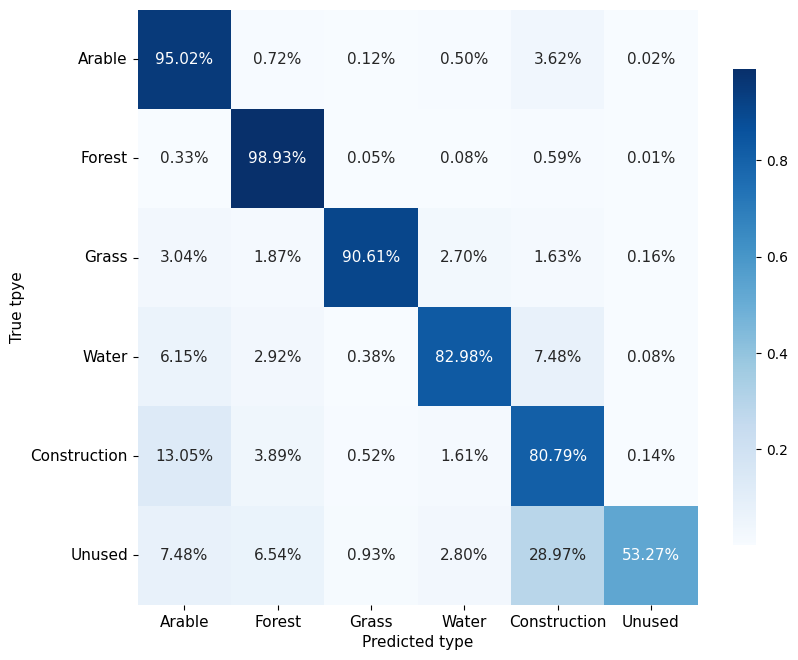

In [59]:
import seaborn as sns


# 将混淆矩阵标准化为比例
conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

# 类别标签
labels = ['Arable', 'Forest', 'Grass', 'Water', 'Construction', 'Unused']
# 生成混淆矩阵图
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix_normalized, annot=True, fmt='.2%', cmap='Blues', cbar=True, annot_kws={'size': 11}, cbar_kws={'shrink': 0.8})

# 设置横纵坐标标签
plt.xticks(ticks=np.arange(len(labels)) + 0.5, labels=labels, rotation=0, fontsize=11)  # 旋转以防止重叠
plt.yticks(ticks=np.arange(len(labels)) + 0.5, labels=labels, rotation=0, fontsize=11)

# 调整左边的边距，确保标签不被截断
plt.subplots_adjust(left=0.2, right=0.9, top=0.95, bottom=0.1)  # 调整上方、右方、左方和下方的边距

# 设置图表标题和标签
# plt.title('Normalized Confusion Matrix')
plt.xlabel('Predicted type', fontsize=11)
plt.ylabel('True tpye', fontsize=11)

plt.savefig('C:\\Users\\yangwei\\Desktop\\figure-3\\conv-7.jpg', dpi=300)  # 替换路径为实际桌面路径
# 显示图像
plt.show()

In [60]:
A_staten = A_state2+1

In [61]:
np.savetxt('C:\\Users\\yangwei\\Desktop\\txt-3\\conv-7.txt', A_staten, fmt='%d')

In [ ]:
#显示混淆矩阵的图片

In [17]:
m = np.zeros((605,755))

In [18]:
m = np.loadtxt('C:/Users/yangwei/Desktop/AN-CA-3-txt/test/3DCNN-AN-CA-10.txt')

In [19]:
m = m-1

In [20]:
predicted_2020_flat = tf.gather_nd(m, T2)